# 📊 P7 — LLM Prompt Benchmark System
## prompt-engineering-lab by ChuksForge

Research-grade multi-task, multi-model evaluation with cost-per-quality analysis.

| | |
|---|---|
| **Tasks** | Summarization · QA · Reasoning · Coding |
| **Models** | GPT-4o-mini · GPT-4o · Claude Haiku · Claude Sonnet 4.6 · Google 2.0 Float · Llama 3 8B |
| **Strategies** | zero_shot · instructed · cot / role_based / test_driven |
| **Metrics** | Task score · Cost (USD) · Quality per dollar · Latency |

---

In [ ]:
import os
# os.environ['OPENAI_API_KEY']     = 'sk-...'
# os.environ['ANTHROPIC_API_KEY']  = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'
import pandas as pd
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
print('Setup complete')

Setup complete


## 1. Preview Tasks & Pricing

In [ ]:
from tasks.task_definitions import TASKS, get_all_cases
from costs import PRICING

print('Tasks:')
for name, task in TASKS.items():
    print(f'  {name:15s} — {len(task["cases"])} cases × {len(task["prompts"])} strategies | metric: {task["metric"]}')

print('\nModel pricing ($/M tokens):')
for model, (inp, out) in PRICING.items():
    print(f'  {model:25s}  in=${inp:.3f}  out=${out:.3f}')

Tasks:
  summarization   — 5 cases × 3 strategies | metric: rouge_composite
  qa              — 5 cases × 3 strategies | metric: factual_accuracy
  reasoning       — 5 cases × 3 strategies | metric: reasoning_score
  coding          — 5 cases × 3 strategies | metric: code_quality

Model pricing ($/M tokens):
  GPT-4o-mini                in=$0.150  out=$0.600
  GPT-4o                     in=$2.500  out=$10.000
  Claude Haiku               in=$0.250  out=$1.250
  Claude Sonnet 4.6          in=$3.000  out=$15.000
  Mistral 7B                 in=$0.070  out=$0.070
  Llama 3 8B                 in=$0.050  out=$0.080
  Llama 3 70B                in=$0.520  out=$0.750
  Gemini Flash               in=$0.075  out=$0.300


## 2. Test Evaluation Engine

In [ ]:
from evaluation import evaluate
from tasks.task_definitions import TASKS

for task_name, task in TASKS.items():
    case = task['cases'][0]
    # Use reference as mock output
    mock_output = case.get('reference', case.get('answer', 'def solution(): return result'))
    result = evaluate(
        task=task_name, case=case, output=mock_output,
        model='GPT-4o-mini', prompt_strategy='test',
        prompt_tokens=200, completion_tokens=100, latency_s=1.0,
    )
    print(f'{task_name:15s}  score={result.task_score:.3f}  cost=${result.cost_usd:.6f}  qpd={result.quality_per_dollar:.2f}')

summarization    score=1.000  cost=$0.000090  qpd=11111.11
qa               score=1.000  cost=$0.000090  qpd=11111.11
reasoning        score=0.600  cost=$0.000090  qpd=6666.67
coding           score=0.283  cost=$0.000090  qpd=3147.78


## 5. Explore Results

In [ ]:
df  = pd.read_csv('results/results.csv')
lb  = pd.read_csv('results/leaderboard.csv')
clb = pd.read_csv('results/cost_leaderboard.csv')
ptl = pd.read_csv('results/leaderboard_per_task.csv')
df  = df[df['error'].isna()|(df['error']=='')].copy()

print('Overall leaderboard:')
print(lb[['rank','model','task_score','quality_per_dollar','latency_s']].to_string(index=False))

print('\nCost efficiency ranking:')
print(clb[['model','quality_per_dollar','cost_usd','task_score']].to_string(index=False))

Overall leaderboard:
 rank             model  task_score  quality_per_dollar  latency_s
    1            GPT-4o      0.8160            594.9080     3.4083
    2      Claude Haiku      0.8133           3904.3148     3.4632
    3       GPT-4o-mini      0.8130          10007.5139     6.1244
    4 Claude Sonnet 4.6      0.8092            313.6181     5.3389
    5  Gemini 2.0 Flash      0.7864           3073.7652     2.4683
    6        Llama 3 8B      0.7363          44272.5404     3.7294

Cost efficiency ranking:
            model  quality_per_dollar  cost_usd  task_score
       Llama 3 8B        44272.540443  0.000022    0.736282
      GPT-4o-mini        10007.513923  0.000152    0.813043
     Claude Haiku         3904.314792  0.000374    0.813345
 Gemini 2.0 Flash         3073.765208  0.000319    0.786378
           GPT-4o          594.908045  0.002512    0.816003
Claude Sonnet 4.6          313.618092  0.004661    0.809175


In [ ]:
print('Per-task averages:')
print(df.groupby(['task','model'])['task_score'].mean().round(3).unstack())

Per-task averages:
model          Claude Haiku  Claude Sonnet 4.6  GPT-4o  GPT-4o-mini  \
task                                                                  
coding                0.943              0.954   0.905        0.912   
qa                    0.900              0.900   0.900        0.900   
reasoning             0.920              0.902   0.973        0.973   
summarization         0.490              0.481   0.485        0.467   

model          Gemini 2.0 Flash  Llama 3 8B  
task                                         
coding                    0.894       0.864  
qa                        0.900       0.867  
reasoning                 0.929       0.796  
summarization             0.423       0.419  


In [ ]:
print('Best strategy per task:')
best = ptl.loc[ptl.groupby(['task'])['task_score'].idxmax()]
print(best[['task','prompt_strategy','task_score','model']].to_string(index=False))

Best strategy per task:
         task prompt_strategy  task_score             model
       coding      instructed      0.9548 Claude Sonnet 4.6
           qa             cot      0.9000      Claude Haiku
    reasoning             cot      1.0000            GPT-4o
summarization      instructed      0.5229      Claude Haiku


## 6. Generate Static Charts


 Generating charts (360 rows)...

  ✓ results\charts.png

 Charts saved to results/


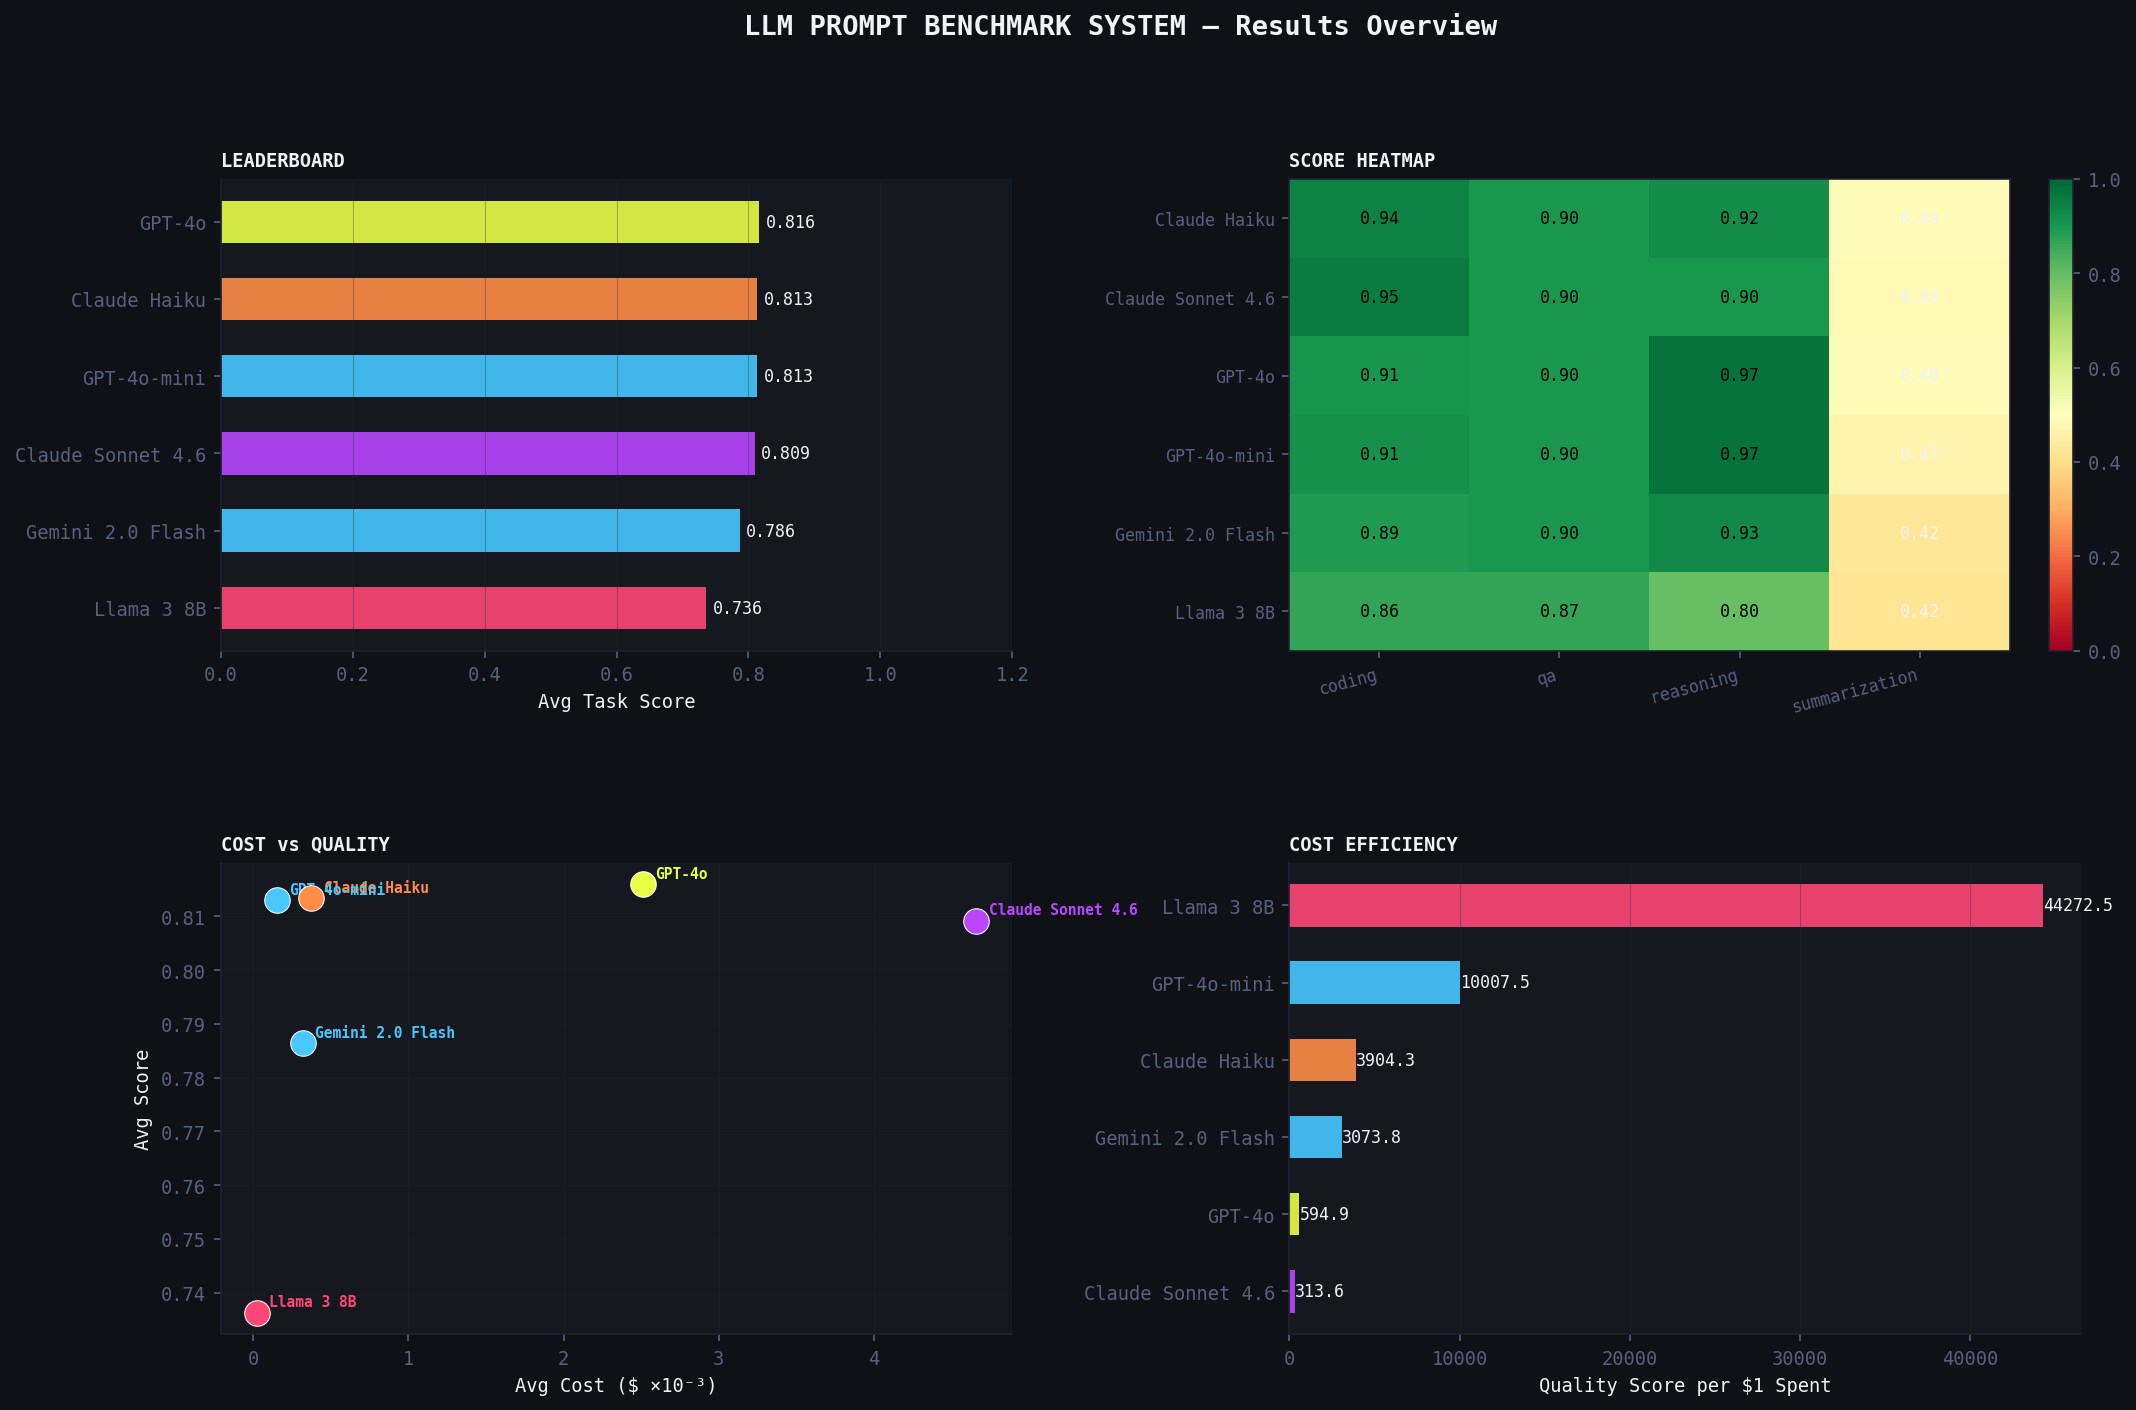

In [ ]:
from visualize import generate_all_charts
generate_all_charts()
from IPython.display import Image
Image('results/charts.png')

## 7. Launch Streamlit Dashboard

In [ ]:
# Launch the interactive dashboard
# Run in terminal (keeps notebook responsive):
# streamlit run dashboard.py
print('Run: streamlit run dashboard.py → http://localhost:8501')

Run: streamlit run dashboard.py → http://localhost:8501


## 8. Auto-Populate README & Findings

In [ ]:
import subprocess
subprocess.run(['python', 'update_findings.py'])

CompletedProcess(args=['python', 'update_findings.py'], returncode=0)

## 9. Key Findings

1. **Best model overall:** `GPT-4o` — avg score 0.816 across all tasks
2. **Best cost efficiency:** `Llama 3 8B` — 44272.5 quality points per $1
3. **Easiest task for models:** `reasoning` — avg score 0.916
4. **Hardest task for models:** `summarization` — avg score 0.461
5. **Best prompt strategy:** `structured` — avg score 0.918
6. **Fastest model:** `Gemini 2.0 Flash` — 2.47s avg latency
7. **Key insight:** The sweet spot in the chat vs quality scatter chart is the Claude 3 Haiku / GPT-4o Mini / Gemini Flash cluster in the top-left — these models deliver scores around 0.81–0.82 at near-zero cost (under $0.2×10⁻³), making them the clear efficiency winners. GPT-4o offers comparable quality (~0.82) but at roughly 10–15× higher cost, while Claude Sonnet 4.6 sits in a difficult position: it matches GPT-4o's quality score but at the highest cost (~$4.5×10⁻³), making it hard to justify unless the use case specifically demands it. Llama 3 8B is the cheapest of all but noticeably lags in quality (~0.74), confirming that the free/open-source option comes with a meaningful performance penalty — the real takeaway being that the mid-tier frontier models have essentially commoditized high quality at low cost, squeezing the value proposition of both the cheapest and most expensive options.

---
*Dashboard: `streamlit run dashboard.py`*


Done.